In [3]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import pandas as pd
import json
import geopandas as gpd
import os

path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

from scripts.helpers.datasets import load_taxi_data
from scripts.helpers.preprocessing import evaluate_weather_zones, get_weather_zone_centers
from scripts.download_weather_data import download_weather_data

# Weather Data Preparation

This notebook prepares the hourly weather data that is later merged with taxi trips to analyse how weather affects demand.

The workflow includes the following steps:

1. **Determine weather zone locations** -- Chicago spans roughly 600 km² and experiences meaningful microclimatic variation across the lakefront, urban core, and far northwest. Rather than picking a single reference point arbitrarily, we use the spatial distribution of taxi pickups to find representative anchor locations via k-means clustering of the pickup coordinates. The cluster centroids become the coordinates from which weather data is fetched.
2. **Identify the time window** -- The required date range for which weather data is needed is derived from the earliest and latest trip timestamps in the taxi data.
3. **Download weather data** -- Hourly weather is fetched from the Open-Meteo API for each zone centroid and saved to `data/raw/chicago_weather_hourly.csv`.
4. **Validate and clean** -- Nulls, duplicates, temporal completeness and value plausibility are checked. The `weather_code` column is dropped since only three WMO categories appear in the data and they are already captured by the continuous `rain` and `snowfall` columns.
5. **Analyse weather impact on demand** -- Bar charts show how temperature, rainfall and wind relate to average hourly trip counts.

In [4]:
from scripts.helpers.datasets import load_weather_data, load_merged_data

df = load_weather_data(preprocessed=True)       # cleaned dataset

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61344 entries, 0 to 61343
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype                          
---  ------                --------------  -----                          
 0   time                  61329 non-null  datetime64[us, America/Chicago]
 1   temperature_2m        61344 non-null  float64                        
 2   apparent_temperature  61344 non-null  float64                        
 3   precipitation         61344 non-null  float64                        
 4   rain                  61344 non-null  float64                        
 5   snowfall              61344 non-null  float64                        
 6   snow_depth            61344 non-null  float64                        
 7   windspeed_10m         61344 non-null  float64                        
 8   windgusts_10m         61344 non-null  float64                        
 9   cloud_cover           61344 non-null  int64                          
 1

## Determining Weather Zone Locations via K-Means Clustering

Weather data from Open-Meteo is requested for specific geographic coordinates. Using a single fixed point (such as O'Hare airport or downtown) would not represent all of Chicago: the lakefront, the far northwest, and the South Side can experience noticeably different temperatures, wind, and precipitation at the same time.

Rather than choosing locations arbitrarily, we let the data decide. We cluster all taxi pickup coordinates using k-means so that the resulting cluster centroids sit at the locations where trips actually concentrate. These centroids become the coordinates passed to the weather API.

The elbow method (inertia) and silhouette score are used together to select k. Inertia rewards smaller clusters; silhouette rewards well-separated ones. The chosen k balances both: enough zones to capture spatial weather variation, few enough to avoid over-engineering the weather representation.

In [ ]:
df = load_taxi_data(preprocessed=True)
coords = df[["pickup_centroid_latitude", "pickup_centroid_longitude"]].dropna().values

In [3]:
# 1. Calculate metrics
metrics = evaluate_weather_zones(coords, k_range=range(2, 10))

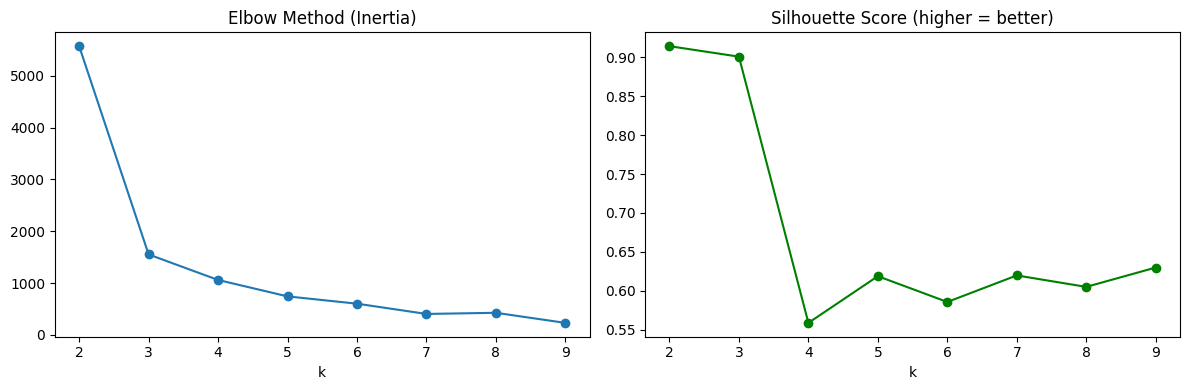

In [4]:
# 2. Visualize metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

metrics["inertia"].plot(ax=ax1, marker="o")
ax1.set_xlabel("k")
ax1.set_title("Elbow Method (Inertia)")

metrics["silhouette"].plot(ax=ax2, marker="o", color="green")
ax2.set_xlabel("k")
ax2.set_title("Silhouette Score (higher = better)")

plt.tight_layout()
plt.show()

In [5]:
# 3. Choose k=3 based on metrics and calculate zone centers + save to JSON
weather_zones = get_weather_zone_centers(coords, n_clusters=3)
with open(ROOT_DIR / "data" / "raw" / "weather_zones.json", "w") as f:
    json.dump(weather_zones, f, indent=4)
print(weather_zones)
# → {'zone_1': (41.88, -87.63), 'zone_2': ..., ...}

{0: (41.88575002073601, -87.62881448348256), 1: (41.97907642975536, -87.90298113721171), 2: (41.785414698041734, -87.74950367730293)}


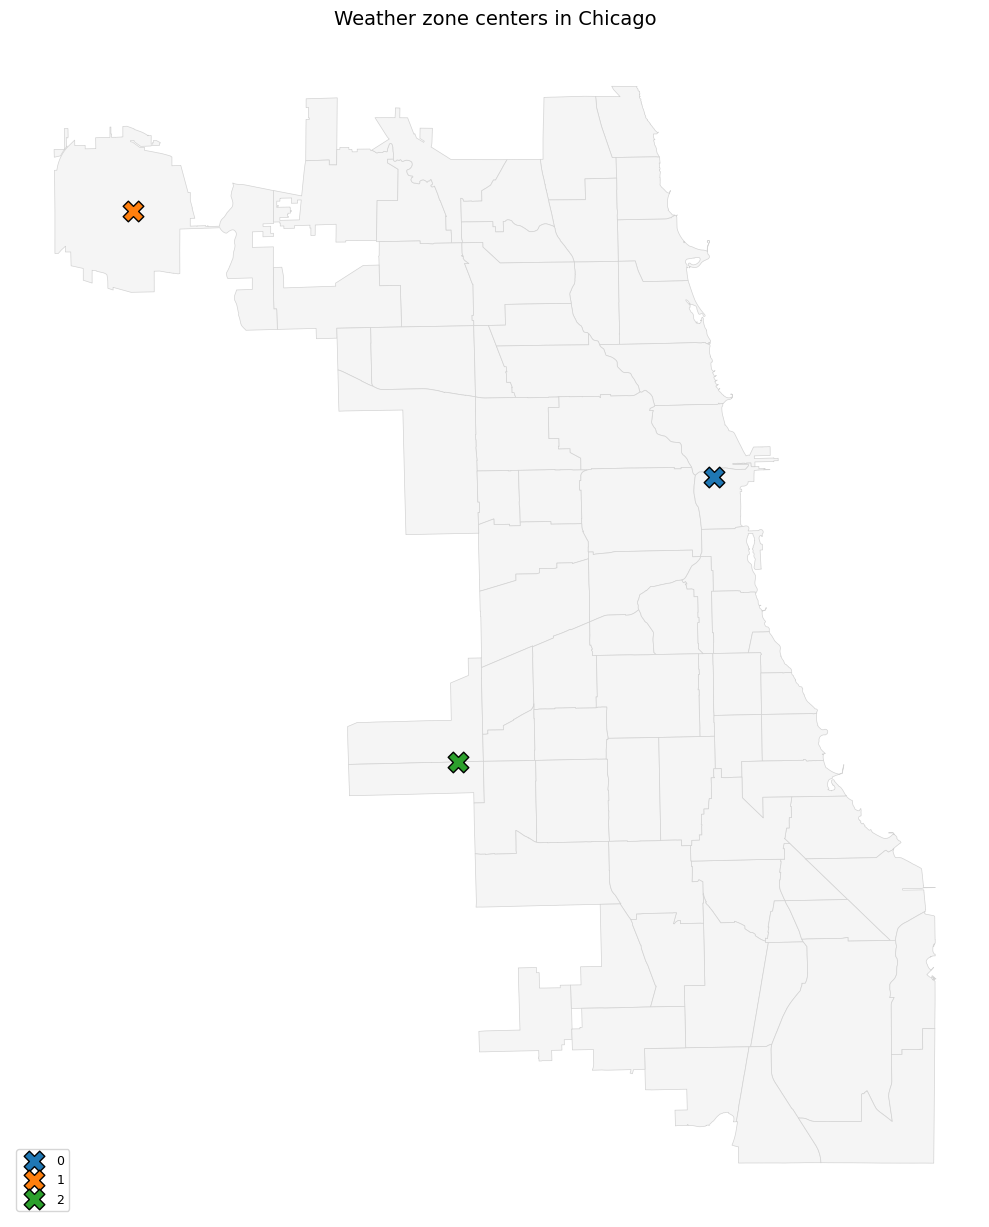

In [6]:
# 4. Plot Chicago basemap + weather zones (zone centers only)
ca_gdf = gpd.read_file(ROOT_DIR / "data" / "raw" / "community_areas.geojson")
if ca_gdf.crs is not None and ca_gdf.crs.to_epsg() != 4326:
    ca_gdf = ca_gdf.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 14))
ca_gdf.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.5)

# Weather zone centers
for zone, (lat, lon) in weather_zones.items():
    ax.scatter(
        lon, lat,
        marker="X", s=220,
        linewidths=1, edgecolors="black",
        label=zone,
    )

ax.legend(loc="lower left", fontsize=9, framealpha=0.8)
ax.set_title("Weather zone centers in Chicago", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Identify the needed timeframe

By searching for the timestamp of the first and last trip we can identify the timeframe for  when we need the weather data

In [31]:
first_trip = df['trip_start_timestamp'].min().date()
last_trip = df['trip_end_timestamp'].max().date()

In [32]:
df_weather = download_weather_data(weather_zones, first_trip, last_trip)
df_weather.sort_values("time", inplace=True, ascending=True)
df_weather.head()

   Period : 2024-01-01 → 2026-05-01
   Zones  : 3

   Fetching 0  (41.8858, -87.6288) … 20,448 rows
   Fetching 1  (41.9791, -87.9030) … 20,448 rows
   Fetching 2  (41.7854, -87.7495) … 20,448 rows

Done.
   Rows saved : 61,344  (3 zones × ~20,448 hours)
   Output     : /home/timo/uni/AAA/AAA26-Chicago-Mobility/data/raw/chicago_weather_hourly.csv


,time,temperature_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,windspeed_10m,windgusts_10m,weather_code,cloud_cover,zone,latitude,longitude
0,2024-01-01 00:00:00,0.6,-6.3,0.1,0.0,0.07,0.01,30.4,45.7,71,100,0,41.885750,-87.628814
20448,2024-01-01 00:00:00,-0.2,-5.6,0.0,0.0,0.00,0.01,18.3,34.2,3,100,1,41.979076,-87.902981
40896,2024-01-01 00:00:00,-0.1,-5.7,0.0,0.0,0.00,0.01,20.0,35.3,3,100,2,41.785415,-87.749504
1,2024-01-01 01:00:00,0.3,-6.5,0.1,0.0,0.07,0.01,30.4,44.3,71,100,0,41.885750,-87.628814
20449,2024-01-01 01:00:00,-0.3,-5.8,0.0,0.0,0.00,0.01,19.1,36.0,3,100,1,41.979076,-87.902981


In [33]:
df_weather.info()

<class 'pandas.DataFrame'>
Index: 61344 entries, 0 to 61343
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  61344 non-null  datetime64[us]
 1   temperature_2m        61344 non-null  float64       
 2   apparent_temperature  61344 non-null  float64       
 3   precipitation         61344 non-null  float64       
 4   rain                  61344 non-null  float64       
 5   snowfall              61344 non-null  float64       
 6   snow_depth            61344 non-null  float64       
 7   windspeed_10m         61344 non-null  float64       
 8   windgusts_10m         61344 non-null  float64       
 9   weather_code          61344 non-null  int64         
 10  cloud_cover           61344 non-null  int64         
 11  zone                  61344 non-null  int64         
 12  latitude              61344 non-null  float64       
 13  longitude             61344 non-

In [34]:
print(df_weather.isnull().sum())

time                    0
temperature_2m          0
apparent_temperature    0
precipitation           0
rain                    0
snowfall                0
snow_depth              0
windspeed_10m           0
windgusts_10m           0
weather_code            0
cloud_cover             0
zone                    0
latitude                0
longitude               0
dtype: int64


## Check for duplicates

In [35]:
print(df_weather.duplicated(subset=['time', 'zone']).sum())

0


There seem to be no duplicates in the dataset, so no further action is needed.

## Weather Codes

The raw `weather_code` column uses WMO (World Meteorological Organization) integer codes ranging from 0–99. These codes are **not ordinal** — a code of 95 (thunderstorm) does not mean "95× worse" than code 1 (clear sky). Feeding raw integers into an SVM or neural network would imply a false numeric ordering that the model would misinterpret.

Instead, the codes are binned into 7 meaningful categories based on the WMO standard:

| Code range | Category |
|---|---|
| 0–3 | clear |
| 45–48 | fog |
| 51–67 | rain (incl. drizzle & freezing rain) |
| 71–77 | snow |
| 80–82 | showers |
| 85–86 | snow showers |
| 95–99 | storm |

Note: codes 4–44 and 68–70 do not exist in the WMO standard — hence the non-continuous boundaries.

In [36]:
def categorize_weather_code(code):
    if code <= 3:
        return "clear"
    elif code <= 48:
        return "fog"
    elif code <= 67:
        return "rain"
    elif code <= 77:
        return "snow"
    elif code <= 82:
        return "showers"
    elif code <= 86:
        return "snow_showers"
    else:
        return "storm"

print(df_weather['weather_code'].apply(categorize_weather_code).unique())

<StringArray>
['snow', 'clear', 'rain']
Length: 3, dtype: str


As it can be seen here, the only weather codes in the dataset that actually appear are clear, snow and rain. Snow and rain are already covered by the numeric columns `snowfall` and `rainfall`, so no new information is added and the weather code column can be discarded.

In [37]:
df_weather.drop(columns=["weather_code"], inplace=True)
print("weather_code" in df_weather.columns)

False


## Dataset completeness

In [ ]:
# check if the weather data is complete in terms of time (per zone)
zones = df_weather['zone'].unique()
total_gaps = 0

for zone in zones:
    zone_data = df_weather[df_weather['zone'] == zone].reset_index(drop=True)
    missing_gaps = []
    
    for idx in range(1, len(zone_data)):
        time_diff = zone_data.loc[idx, "time"] - zone_data.loc[idx - 1, "time"]
        if time_diff != pd.Timedelta(hours=1):
            missing_gaps.append(idx)
    
    if missing_gaps:
        total_gaps += len(missing_gaps)
        print(f"\n{'='*80}")
        print(f"Zone: {zone} — {len(missing_gaps)} gaps found")
        print(f"{'='*80}\n")
        
        for gap_idx in missing_gaps[:3]:
            print(f"Gap at row {gap_idx}:")
            print("-" * 80)
            
            start = max(0, gap_idx - 2)
            end = min(len(zone_data), gap_idx + 3)
            
            display_df = zone_data.iloc[start:end][['time', 'temperature_2m', 'precipitation', 'rain']].copy()
            display_df['time_diff_hours'] = display_df['time'].diff().dt.total_seconds() / 3600
            print(display_df.to_string(index=True))
            print()
        
        if len(missing_gaps) > 5:
            print(f"... and {len(missing_gaps) - 5} more gaps in {zone}\n")
    else:
        print(f"✓ Zone {zone}: No missing data gaps — dataset is complete!")

print(f"\n{'='*80}")
print(f"SUMMARY: {total_gaps} total gaps across all zones")

✓ Zone 0: No missing data gaps — dataset is complete!
✓ Zone 1: No missing data gaps — dataset is complete!
✓ Zone 2: No missing data gaps — dataset is complete!

SUMMARY: 0 total gaps across all zones


## Outlier Analysis

In [40]:
weather_cols = ['temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'windspeed_10m', 'windgusts_10m', 'cloud_cover']
df_weather[weather_cols].describe(percentiles=[0.25, 0.5, 0.9, 0.99])

,temperature_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,windspeed_10m,windgusts_10m,cloud_cover
count,61344.000000,61344.000000,61344.000000,61344.000000,61344.000000,61344.000000,61344.000000,61344.000000,61344.000000
mean,9.974899,7.635234,0.111646,0.100057,0.008134,0.011551,12.694314,27.202352,58.393209
std,11.435817,13.760939,0.598286,0.587672,0.074303,0.036501,6.426776,12.528114,43.947500
min,-26.800000,-32.900000,0.000000,0.000000,0.000000,0.000000,0.000000,1.100000,0.000000
25%,1.500000,-2.900000,0.000000,0.000000,0.000000,0.000000,7.900000,17.600000,4.000000
50%,10.100000,7.200000,0.000000,0.000000,0.000000,0.000000,11.700000,25.900000,83.000000
90%,24.500000,25.900000,0.100000,0.100000,0.000000,0.030000,21.500000,44.300000,100.000000
99%,31.600000,34.100000,2.700000,2.600000,0.210000,0.200000,31.300000,60.800000,100.000000
max,36.300000,41.300000,19.800000,19.800000,3.360000,0.300000,45.100000,112.000000,100.000000


The weather data appears plausible for Chicago: temperatures range from −26.8°C to 36.3°C (with apparent temperatures as low as −32.9°C due to wind chill), consistent with the city's continental climate. Precipitation, wind and cloud cover distributions are likewise realistic, with near-zero median hourly precipitation and high median cloud cover (83%) reflecting Chicago's characteristically overcast skies.

## Weather-driven Demand

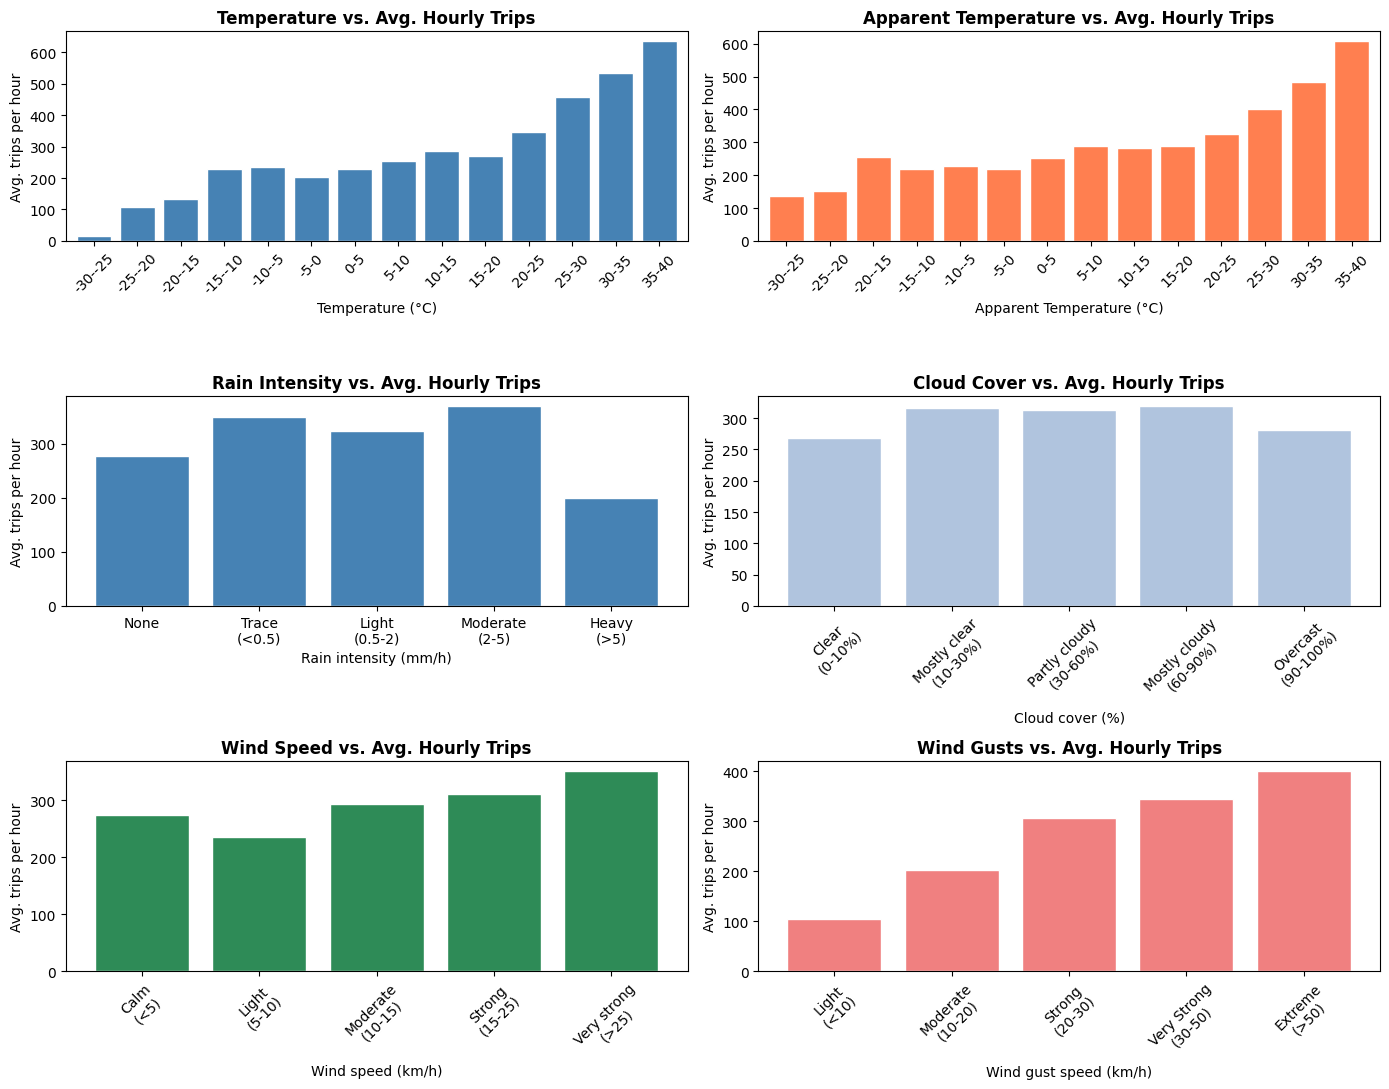

In [ ]:
from scripts.helpers.datasets import load_taxi_data, load_weather_data

# Hourly trip counts from taxi data
_taxi = load_taxi_data(preprocessed=True)
_taxi["hour"] = _taxi["trip_start_timestamp"].dt.floor("h")
trips_per_hour = _taxi.groupby("hour").size().rename("trips")

# City-wide hourly weather: average across zones, 2024 only
_weather = load_weather_data(preprocessed=True)
weather_hourly = (
    _weather[_weather["time"].dt.year == 2024]
    .groupby("time")[["temperature_2m", "apparent_temperature", "rain", "cloud_cover", "windspeed_10m", "windgusts_10m"]]
    .mean()
    .rename_axis("hour")
)

hourly = trips_per_hour.to_frame().join(weather_hourly, how="inner")

# Define bins for all weather variables
temp_bins = list(range(-30, 41, 5))
temp_labels = [f"{a}-{b}" for a, b in zip(temp_bins[:-1], temp_bins[1:])]
hourly["temp_bin"] = pd.cut(hourly["temperature_2m"], bins=temp_bins, labels=temp_labels)

app_temp_bins = list(range(-30, 41, 5))
app_temp_labels = [f"{a}-{b}" for a, b in zip(app_temp_bins[:-1], app_temp_bins[1:])]
hourly["app_temp_bin"] = pd.cut(hourly["apparent_temperature"], bins=app_temp_bins, labels=app_temp_labels)

rain_bins = [-0.01, 0, 0.5, 2, 5, 25]
rain_labels = ["None", "Trace\n(<0.5)", "Light\n(0.5-2)", "Moderate\n(2-5)", "Heavy\n(>5)"]
hourly["rain_bin"] = pd.cut(hourly["rain"], bins=rain_bins, labels=rain_labels)

cloud_bins = [0, 10, 30, 60, 90, 100]
cloud_labels = ["Clear\n(0-10%)", "Mostly clear\n(10-30%)", "Partly cloudy\n(30-60%)", 
                "Mostly cloudy\n(60-90%)", "Overcast\n(90-100%)"]
hourly["cloud_bin"] = pd.cut(hourly["cloud_cover"], bins=cloud_bins, labels=cloud_labels, include_lowest=True)

wind_bins = [-0.01, 5, 10, 15, 25, 100]
wind_labels = ["Calm\n(<5)", "Light\n(5-10)", "Moderate\n(10-15)", "Strong\n(15-25)", "Very strong\n(>25)"]
hourly["wind_bin"] = pd.cut(hourly["windspeed_10m"], bins=wind_bins, labels=wind_labels)

gust_bins = [-0.01, 10, 20, 30, 50, 100]
gust_labels = ["Light\n(<10)", "Moderate\n(10-20)", "Strong\n(20-30)", "Very Strong\n(30-50)", "Extreme\n(>50)"]
hourly["gust_bin"] = pd.cut(hourly["windgusts_10m"], bins=gust_bins, labels=gust_labels)

# Create 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(14, 11))

# [0, 0] Temperature
hourly.groupby("temp_bin", observed=True)["trips"].mean().plot(
    kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="white", width=0.8
)
axes[0, 0].set_title("Temperature vs. Avg. Hourly Trips", fontweight="bold")
axes[0, 0].set_xlabel("Temperature (°C)")
axes[0, 0].set_ylabel("Avg. trips per hour")
axes[0, 0].tick_params(axis="x", rotation=45)

# [0, 1] Apparent Temperature
hourly.groupby("app_temp_bin", observed=True)["trips"].mean().plot(
    kind="bar", ax=axes[0, 1], color="coral", edgecolor="white", width=0.8
)
axes[0, 1].set_title("Apparent Temperature vs. Avg. Hourly Trips", fontweight="bold")
axes[0, 1].set_xlabel("Apparent Temperature (°C)")
axes[0, 1].set_ylabel("Avg. trips per hour")
axes[0, 1].tick_params(axis="x", rotation=45)

# [1, 0] Rain
hourly.groupby("rain_bin", observed=True)["trips"].mean().plot(
    kind="bar", ax=axes[1, 0], color="steelblue", edgecolor="white", width=0.8
)
axes[1, 0].set_title("Rain Intensity vs. Avg. Hourly Trips", fontweight="bold")
axes[1, 0].set_xlabel("Rain intensity (mm/h)")
axes[1, 0].set_ylabel("Avg. trips per hour")
axes[1, 0].tick_params(axis="x", rotation=0)

# [1, 1] Cloud Cover
hourly.groupby("cloud_bin", observed=True)["trips"].mean().plot(
    kind="bar", ax=axes[1, 1], color="lightsteelblue", edgecolor="white", width=0.8
)
axes[1, 1].set_title("Cloud Cover vs. Avg. Hourly Trips", fontweight="bold")
axes[1, 1].set_xlabel("Cloud cover (%)")
axes[1, 1].set_ylabel("Avg. trips per hour")
axes[1, 1].tick_params(axis="x", rotation=45)

# [2, 0] Wind Speed
hourly.groupby("wind_bin", observed=True)["trips"].mean().plot(
    kind="bar", ax=axes[2, 0], color="seagreen", edgecolor="white", width=0.8
)
axes[2, 0].set_title("Wind Speed vs. Avg. Hourly Trips", fontweight="bold")
axes[2, 0].set_xlabel("Wind speed (km/h)")
axes[2, 0].set_ylabel("Avg. trips per hour")
axes[2, 0].tick_params(axis="x", rotation=45)

# [2, 1] Wind Gusts
hourly.groupby("gust_bin", observed=True)["trips"].mean().plot(
    kind="bar", ax=axes[2, 1], color="lightcoral", edgecolor="white", width=0.8
)
axes[2, 1].set_title("Wind Gusts vs. Avg. Hourly Trips", fontweight="bold")
axes[2, 1].set_xlabel("Wind gust speed (km/h)")
axes[2, 1].set_ylabel("Avg. trips per hour")
axes[2, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Loading & Preprocessing in Subsequent Notebooks

All steps documented above are encapsulated in two helper scripts so that later notebooks can load a clean dataset in a single line:

- **`scripts/helpers/datasets.py`** — entry point for loading any dataset. `load_weather_data(preprocessed=True)` reads the raw CSV and optionally applies the full preprocessing pipeline.
- **`scripts/helpers/preprocessing.py`** — contains `preprocess_weather_data()`, which drops irrelavant rows, handles weather_code and returns a clean `DataFrame`.

Usage in any subsequent notebook:

```python
from scripts.helpers.datasets import load_weather_data, load_merged_data

df = load_weather_data(preprocessed=True)       # cleaned dataset
df_raw = load_weather_data(preprocessed=False)  # raw data only
df_merged = load_merged_data() # preprocessed taxi + weather data
```